In [104]:
from torchvision.datasets import FashionMNIST
from typing import Dict, Tuple
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
from IPython.display import HTML
# !pip install torch-fidelity

## Utils

In [105]:
def unorm(x):
  return (x - x.min()) / (x.max() - x.min())

In [106]:
def plot_sample(samples, n_sample, nrows):
    ncols = n_sample//nrows
    samples = unorm(samples.cpu())
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 10))

    axes = axes.flatten()

    for i in range(n_sample):
        image = samples[i]
        
        if image.shape[0] == 1:
            image = image.squeeze(0)
            axes[i].imshow(image, cmap='gray')
        else:
            image = image.permute(1, 2, 0)
            axes[i].imshow(image)

        axes[i].axis('off')  
        axes[i].set_title(f'Image {i + 1}') 

    for j in range(n_sample, nrows * ncols):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

## hyperparameters


In [107]:
timesteps = 1000
beta1 = 1e-4
beta2 = 0.02

device = torch.device("cuda:0" if torch.cuda.is_available() else torch.device('cpu'))
n_feat = 64 
n_cfeat = 10 
height = 32 
save_dir = '/content/'

batch_size = 100
n_epoch = 30 
lrate = 6e-4

## FashionMNIST Dataset

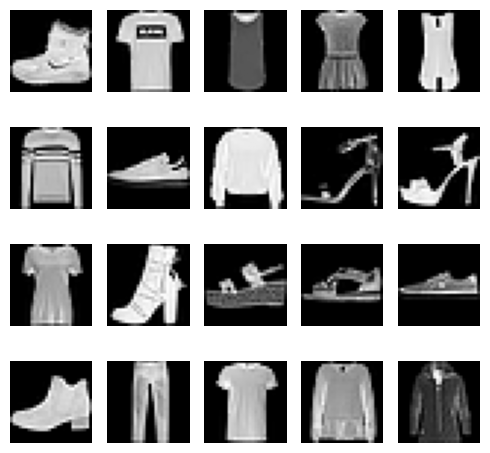

In [109]:
temp_dataset = FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
fig, axes = plt.subplots(4, 5, figsize=(5, 5))
axes = axes.flatten()
for i in range(20):
    img, label = temp_dataset[i]
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [110]:
transform = transforms.Compose([
    transforms.Resize((height, height)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [111]:
train_dataset = FashionMNIST(root='./data', train=True, download=True, transform=transform)
val_dataset = FashionMNIST(root='./data', train=False, download=True, transform=transform)

In [112]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

## UNet

So what model do we use to do this magical 'denoising' step? We've looked a little at basic convolutional neural networks that take in an image and output something like a classification. And we've seen autoencoders that go from an image down to a latent representation and back to an output image. Perhaps one of these would be suitable?

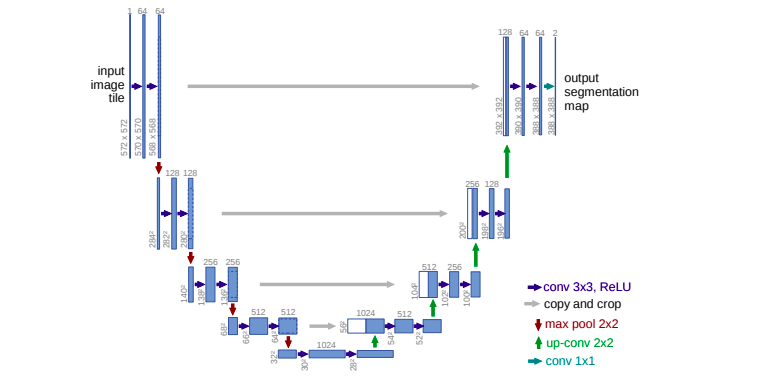

(Unet diagram from [the 2015 paper](https://arxiv.org/abs/1505.04597))

One issue with a typical 'bottlekneck' architecture like an autoencoder is that by design they loose the details around exact pixel coordinates. To get around this, an architecture called the Unet was introduced. Originally designed for segmentation tasks, the architecture (shown above) passes information from high-resolution, early layers to later layers. These 'shortcuts' let the network use detailed features from the original image while also capturing more high-level semantic information from the deeper layers.

These networks turned out to be great at all sorts of image-to-image tasks. Colorization , segmentation and so on. These days, typical unet models incorporate ideas such as attention and can be built around pretrained 'backbones' like resnet-50 for transfer learning tasks.

The implementation below is a fairly typical modern Unet with one extra trick: a TimeEmbedding which encodes the time step (t) and lets the model use this as conditioning information by passing it in in the middle of the network. Take a peek at the code and see if you can figure out roughly what's going on in the forward pass.



In [113]:
class ResidualConvBlock(nn.Module):
    def __init__(
        self, in_channels: int, out_channels: int, is_res: bool = False
    ) -> None:
        super().__init__()

        self.same_channels = in_channels == out_channels

        self.is_res = is_res

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1),   
            nn.BatchNorm2d(out_channels),  
            nn.GELU(),   
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 3, 1, 1),   
            nn.BatchNorm2d(out_channels),   
            nn.GELU(),   
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        if self.is_res:
            x1 = self.conv1(x)

            x2 = self.conv2(x1)

            if self.same_channels:
                out = x + x2
            else:
                shortcut = nn.Conv2d(x.shape[1], x2.shape[1], kernel_size=1, stride=1, padding=0).to(x.device)
                out = shortcut(x) + x2

            return out / 1.414

        else:
            x1 = self.conv1(x)
            x2 = self.conv2(x1)
            return x2

    def get_out_channels(self):
        return self.conv2[0].out_channels

    def set_out_channels(self, out_channels):
        self.conv1[0].out_channels = out_channels
        self.conv2[0].in_channels = out_channels
        self.conv2[0].out_channels = out_channels



class UnetUp(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UnetUp, self).__init__()

        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, 2, 2),
            ResidualConvBlock(out_channels, out_channels),
            ResidualConvBlock(out_channels, out_channels),
        ]

        self.model = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = torch.cat((x, skip), 1)

        x = self.model(x)
        return x


class UnetDown(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UnetDown, self).__init__()

        layers = [ResidualConvBlock(in_channels, out_channels), ResidualConvBlock(out_channels, out_channels), nn.MaxPool2d(2)]

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class EmbedFC(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super(EmbedFC, self).__init__()
        '''
        This class defines a generic one layer feed-forward neural network for embedding input data of
        dimensionality input_dim to an embedding space of dimensionality emb_dim.
        '''
        self.input_dim = input_dim

        layers = [
            nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),
        ]

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(-1, self.input_dim)
        return self.model(x)

In [114]:
class Unet(nn.Module):
    def __init__(self, in_channels, n_feat=256, n_cfeat=10, height=28): 
        super(Unet, self).__init__()

        self.in_channels = in_channels
        self.n_feat = n_feat
        self.n_cfeat = n_cfeat
        self.h = height 

        self.init_conv = ResidualConvBlock(in_channels, n_feat, is_res=True)

        self.down1 = UnetDown(n_feat, n_feat)        
        self.down2 = UnetDown(n_feat, 2 * n_feat)   

        self.to_vec = nn.Sequential(nn.AdaptiveAvgPool2d((1,1)), nn.GELU())

        self.timeembed1 = EmbedFC(1, 2*n_feat)
        self.timeembed2 = EmbedFC(1, 1*n_feat)
        self.contextembed1 = EmbedFC(n_cfeat, 2*n_feat)
        self.contextembed2 = EmbedFC(n_cfeat, 1*n_feat)

        self.up0 = nn.Sequential(
            nn.ConvTranspose2d(2 * n_feat, 2 * n_feat, self.h//4, self.h//4),
            nn.GroupNorm(8, 2 * n_feat), 
            nn.ReLU(),
        )
        self.up1 = UnetUp(4 * n_feat, n_feat)
        self.up2 = UnetUp(2 * n_feat, n_feat)

        self.out = nn.Sequential(
            nn.Conv2d(2 * n_feat, n_feat, 3, 1, 1), 
            nn.GroupNorm(8, n_feat), 
            nn.ReLU(),
            nn.Conv2d(n_feat, self.in_channels, 3, 1, 1), 
        )

    def forward(self, x, t, c=None):
        """
        x : (batch, n_feat, h, w) : input image
        t : (batch, n_cfeat)      : time step
        c : (batch, n_classes)    : context label
        """

        x = self.init_conv(x)
        down1 = self.down1(x)       
        down2 = self.down2(down1)   

        hiddenvec = self.to_vec(down2)

        if c is None:
            c = torch.zeros(x.shape[0], self.n_cfeat).to(x)

        cemb1 = self.contextembed1(c).view(-1, self.n_feat * 2, 1, 1)     
        temb1 = self.timeembed1(t).view(-1, self.n_feat * 2, 1, 1)
        cemb2 = self.contextembed2(c).view(-1, self.n_feat, 1, 1)
        temb2 = self.timeembed2(t).view(-1, self.n_feat, 1, 1)


        up1 = self.up0(hiddenvec)
        up2 = self.up1(cemb1*up1 + temb1, down2)  
        up3 = self.up2(cemb2*up2 + temb2, down1)
        out = self.out(torch.cat((up3, x), 1))
        return out

## Training

In [115]:
nn_model = Unet(in_channels=1, n_feat=n_feat, n_cfeat=n_cfeat, height=height).to(device)

In [116]:
optim = torch.optim.Adam(nn_model.parameters(), lr=lrate)

We want to set up a "**variance schedule**" β, where $\beta_t$ specifies how much noise we want to add at that step. You get fancy schedules but we'll stick with a linear one for now. \\
At each time step t, the variance of the noise added to the previous step is predetermined by the variance schedule, and it's marked as $\beta_t$, where 0 < $\beta_1$ < $\beta_t$ < $\beta_2$ < 1.

In [117]:
b_t = torch.linspace(beta1, beta2, timesteps).to(device)

a_t = 1.0 - b_t

ab_t = torch.cumprod(a_t, dim=0)

### Forward

Now, we want to train our model at different time steps and we don't particulary want to iterativly add little bits of noise a bunch of times just to train one sample.

Luckily, some smart people did some fancy maths (link https://lilianweng.github.io/posts/2018-08-12-vae/#reparameterization-trick) using something called the reparameterization trick that lets us get $x_t$ for any t given $x_0$.

$\begin{aligned}
q(\mathbf{x}_t \vert \mathbf{x}_0) &= \mathcal{N}(\mathbf{x}_t; \sqrt{\bar{\alpha}_t} \mathbf{x}_0, (1 - \bar{\alpha}_t)\mathbf{I})
\end{aligned}$ where $\bar{\alpha}_t = \prod_{i=1}^T \alpha_i$


In [118]:
def perturb_input(x0, t):

    noise = torch.randn_like(x0)


    A = torch.sqrt(ab_t[t]).view(-1, 1, 1, 1)
    B = torch.sqrt(1 - ab_t[t]).view(-1, 1, 1, 1)

    x_t = A * x0 + B * noise

    return x_t, noise

### Train Diffsion

Now that we have our 'diffusion model' defined, we need to train it to predict the noise given $x_t$ and $t$.

Epoch 1 | loss: 0.0512: 100%|██████████| 600/600 [01:11<00:00,  8.36it/s]


Epoch 1 finished. Average Loss: 0.1025


Epoch 2 | loss: 0.0485: 100%|██████████| 600/600 [01:12<00:00,  8.29it/s]


Epoch 2 finished. Average Loss: 0.0594


Epoch 3 | loss: 0.0458: 100%|██████████| 600/600 [01:12<00:00,  8.30it/s]


...

Epoch 28 finished. Average Loss: 0.0274


Epoch 29 | loss: 0.0171: 100%|██████████| 600/600 [01:12<00:00,  8.31it/s]


Epoch 29 finished. Average Loss: 0.0274


Epoch 30 | loss: 0.0208: 100%|██████████| 600/600 [01:12<00:00,  8.30it/s]


Epoch 30 finished. Average Loss: 0.0272


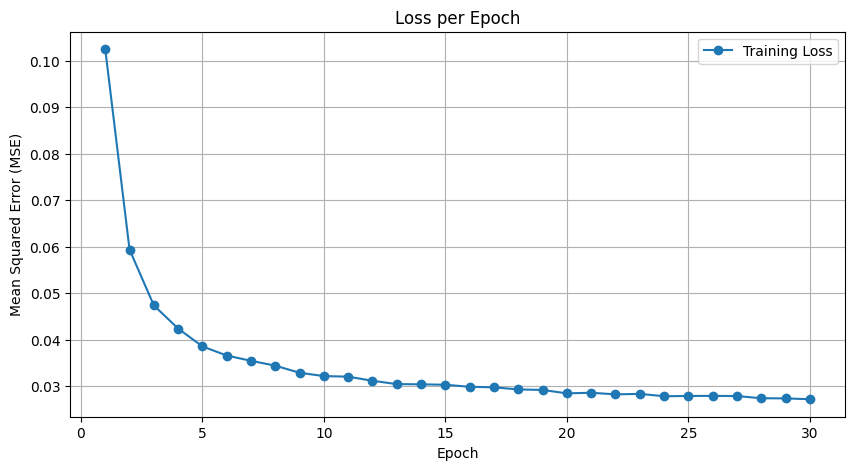

In [119]:
epoch_losses = []

nn_model.train()

for ep in range(n_epoch):
    
    running_loss = 0.0
    
    pbar = tqdm(train_dataloader, mininterval=2)
    
    for x, _ in pbar:
        x = x.to(device)

        optim.zero_grad()

        t = torch.randint(0, timesteps, (x.shape[0],)).to(device)

        x_t, noise = perturb_input(x, t)

        pred_noise = nn_model(x_t, t.float(), c=None)

        loss = ((noise - pred_noise) ** 2).mean()

        loss.backward()
        optim.step()

        running_loss += loss.item()
        
        pbar.set_description(f"Epoch {ep+1} | loss: {loss.item():.4f}")

    avg_epoch_loss = running_loss / len(train_dataloader)
    epoch_losses.append(avg_epoch_loss)
    
    print(f"Epoch {ep+1} finished. Average Loss: {avg_epoch_loss:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epoch + 1), epoch_losses, marker='o', label='Training Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.legend()
plt.show()

## DDPM Sampling

Now we need to define the reverse step $p_\theta(\mathbf{x}_{t-1} \vert \mathbf{x}_t)$

See that little $_\theta$? That often indicates 'learned parameters' - in this case our unet model! We use our model to predict the noise and then 'undo' the forward noise steps one at a time to go from an image that is pure noise to one that looks like a real image. \\
Below image show the sampling algorithm

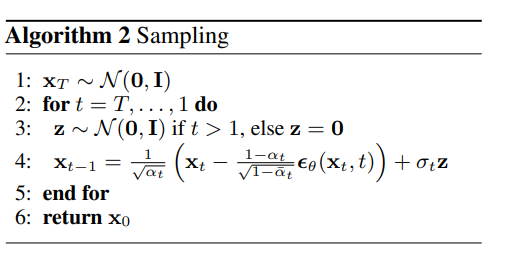

In [120]:
@torch.no_grad()
def sample_ddpm(n_sample):
    nn_model.eval()
    samples = torch.randn(n_sample, 1, height, height).to(device)


    for i in range(timesteps - 1, -1, -1):
        
        if i > 0:
            z = torch.randn_like(samples)
        else:
            z = 0
        
            
        t = torch.tensor([i] * n_sample).to(device).float()
        pred_noise = nn_model(samples, t, c=None)

        A = 1 / torch.sqrt(a_t[i])
        B = (1 - a_t[i]) / torch.sqrt(1 - ab_t[i])
        sigma_t = torch.sqrt(b_t[i]) 
        samples = A * (samples - B * pred_noise) + sigma_t * z
    nn_model.train() 
    return samples

## DDIM Sampling

In [143]:
@torch.no_grad()
def sample_ddim(n_sample, n=20):
    nn_model.eval()
    
    samples = torch.randn(n_sample, 1, height, height).to(device)


    step_indices = torch.linspace(0, timesteps - 1, n, dtype=torch.long)

    step_indices = torch.flip(step_indices, [0]) 

    for i, t_index in enumerate(step_indices):

        t = torch.full((n_sample,), t_index, device=device, dtype=torch.long)


        pred_noise = nn_model(samples, t.float(), c=None)


        alpha_bar_t = ab_t[t_index]
        
        if i < n - 1:
            prev_t_index = step_indices[i + 1]
            alpha_bar_t_prev = ab_t[prev_t_index]
        else:
            alpha_bar_t_prev = torch.tensor(1.0).to(device)

        sqrt_alpha_bar_t = torch.sqrt(alpha_bar_t)
        sqrt_one_minus_alpha_bar_t = torch.sqrt(1 - alpha_bar_t)
        
        predicted_x0 = (samples - sqrt_one_minus_alpha_bar_t * pred_noise) / sqrt_alpha_bar_t
        predicted_x0 = torch.clamp(predicted_x0, -1, 1)

        dir_xt = (samples - sqrt_alpha_bar_t * predicted_x0) / sqrt_one_minus_alpha_bar_t
        
        samples = torch.sqrt(alpha_bar_t_prev) * predicted_x0 + \
                  torch.sqrt(1 - alpha_bar_t_prev) * dir_xt

    return samples

## Results

In [122]:
samples = sample_ddpm(50)

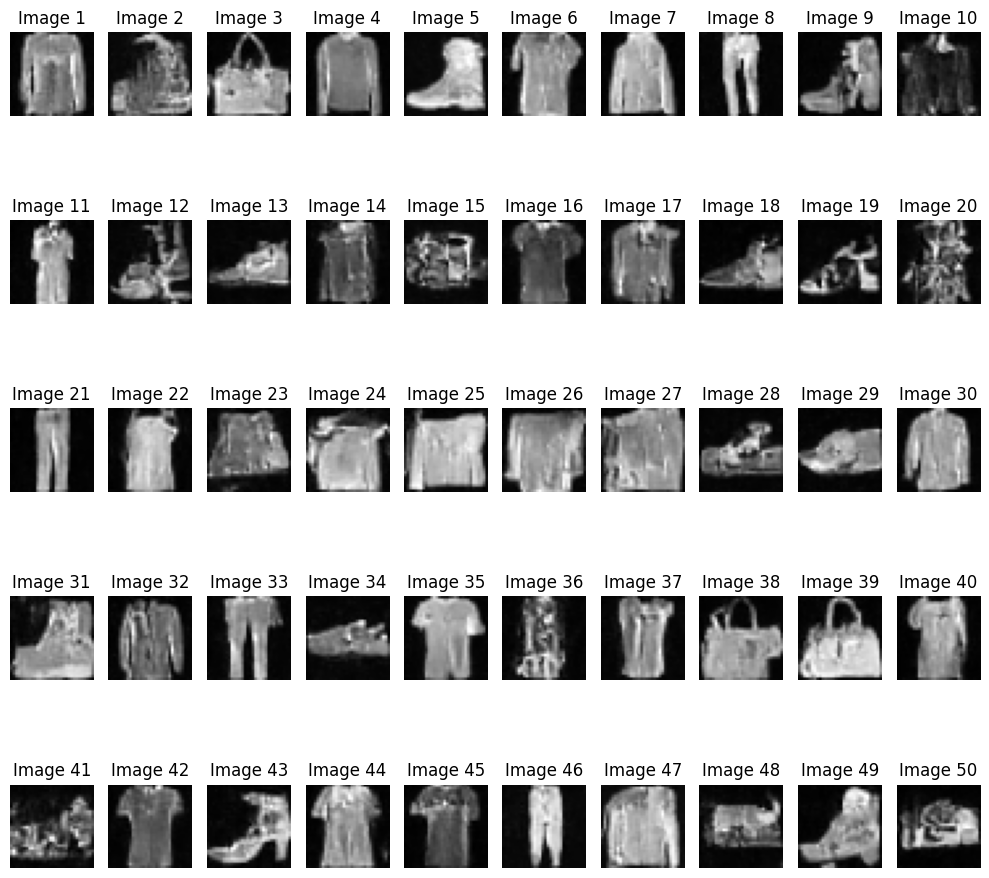

In [123]:
plot_sample(samples, 50, 5)

In [144]:
samples = sample_ddim(50)

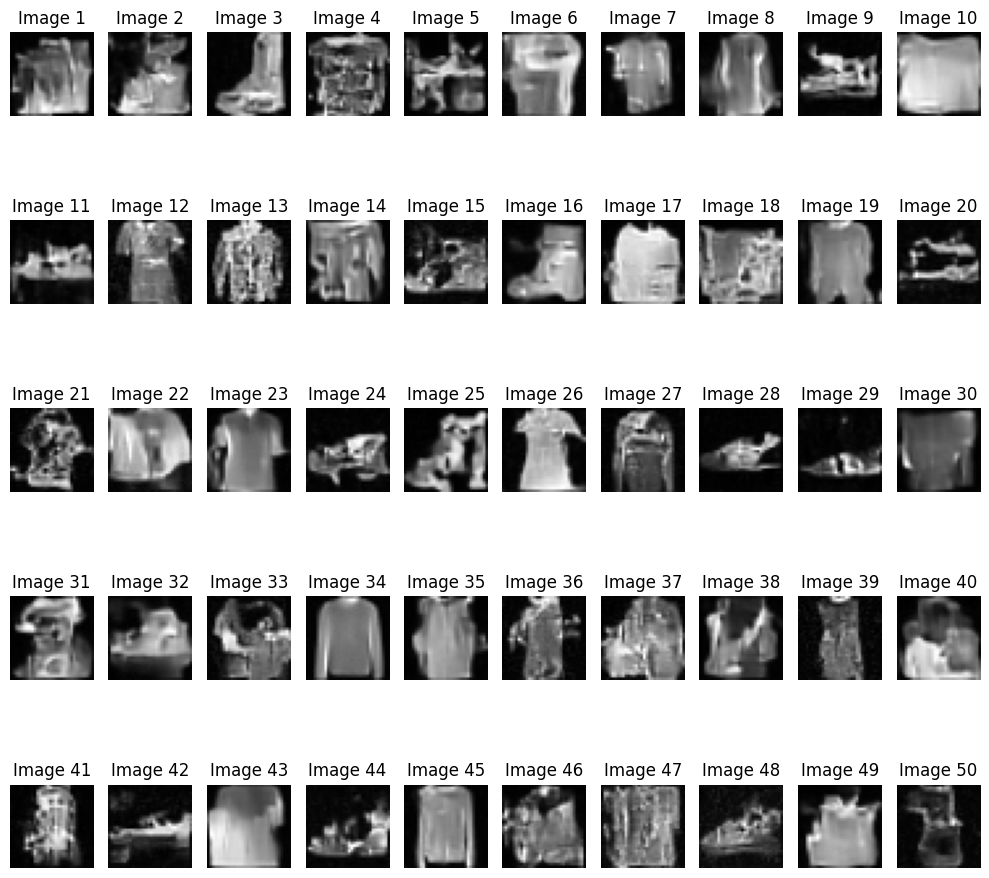

In [145]:
plot_sample(samples, 50, 5)

# Compare DDIM and DDPM Time

In [146]:
%timeit -r 1 sample_ddim(50)
%timeit -r 1 sample_ddpm(50)

406 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
21 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


# Evaluating the Generated Samples:

Now we want to evaluate our model. For this, we use the FID score.

First, read this link to become familiar with this metric and its usage in your code.

In [147]:
from torchmetrics.image.fid import FrechetInceptionDistance
import torch_fidelity

def preprocess(images):
    images = (images + 1) / 2
    
    images = torch.clamp(images, 0, 1)
    
    if images.shape[1] == 1:
        images = images.repeat(1, 3, 1, 1)
        
    images = (images * 255).to(torch.uint8)
    return images


real_images, _ = next(iter(val_dataloader))
real_images = real_images.to(device)
real_images_rgb = preprocess(real_images)
n_samples = real_images.shape[0]

print(f"{n_samples} samples were used in evaluation")


generated_ddpm = sample_ddpm(n_samples)
generated_ddpm = preprocess(generated_ddpm)

fid_ddpm = FrechetInceptionDistance(feature=64).to(device)
fid_ddpm.update(real_images_rgb, real=True)
fid_ddpm.update(generated_ddpm, real=False)
score_ddpm = fid_ddpm.compute()


generated_ddim = sample_ddim(n_samples)
generated_ddim = preprocess(generated_ddim)

fid_ddim = FrechetInceptionDistance(feature=64).to(device)
fid_ddim.update(real_images_rgb, real=True)
fid_ddim.update(generated_ddim, real=False)
score_ddim = fid_ddim.compute()


print(f"DDPM (1000 steps): {score_ddpm.item():.4f}")
print(f"DDIM (20 steps)  : {score_ddim.item():.4f}")



100 samples were used in evaluation
DDPM (1000 steps): 1.0327
DDIM (20 steps)  : 1.5964
